# ReExam 2025

**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Danish Consumption](#toc1_)    
  - 1.1. [Question 1](#toc1_1_)    
  - 1.2. [Question 2](#toc1_2_)    
  - 1.3. [Question 3](#toc1_3_)    
- 2. [Problem 2: Labor supply with non-linear pay schedules](#toc2_)    
  - 2.1. [Question 1](#toc2_1_)    
  - 2.2. [Question 2](#toc2_2_)    
- 3. [Problem 3: Labor market simulation](#toc3_)    
  - 3.1. [Question 1](#toc3_1_)    
  - 3.2. [Compare low- vs high-skilled](#toc3_2_)    
  - 3.3. [Question 3](#toc3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# statsmodels
from statsmodels.tsa.seasonal import STL

# Denmark Statistics API (dstapi)
from dstapi import DstApi

## 1. <a id='toc1_'></a>[Problem 1: Danish Consumption](#toc0_)


### 1.1. <a id='toc1_1_'></a>[Question 1](#toc0_)

In [2]:
NKSO2 = DstApi('NKSO2')
display(NKSO2.tablesummary(language='en'))

Table NKSO2: 2.1.2-3.1 Allocation and 
use of income (summary table) by transaction, sector and time
Last update: 2025-12-22T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,TRANSAKT,59,B2A3GK,B.2g+B.3g Gross operating surplus and mixed inc.,B9D,B.9 Net lending (+)/net borrowing (-),False
1,SEKTOR,7,S1,S.1 Total economy,S2,S.2 Rest of the world,False
2,Tid,107,1999K1,1999Q1,2025K3,2025Q3,True


In [3]:
print('TRANSAKT variable:')
TRANSAKT_dict = {row.id:row.text for row in NKSO2.variable_levels('TRANSAKT',language='en').itertuples()}
TRANSAKT = ['B6GD','P3D']
for varname in TRANSAKT:  print(f'Variable: {varname} - {TRANSAKT_dict[varname]}')

print('\nSEKTOR variable:')
SEKTOR_dict = {row.id:row.text for row in NKSO2.variable_levels('SEKTOR',language='en').itertuples()}
SEKTOR = ['S1M']
for varname in SEKTOR:  print(f'Variable: {varname} - {SEKTOR_dict[varname]}')

TRANSAKT variable:
Variable: B6GD - B.6g Disposable income, gross
Variable: P3D - P.3 Final consumption expenditure

SEKTOR variable:
Variable: S1M - S.14+S.15 Households and non-profit institutions serving households


In [4]:
# a. download
params = {
    'table': 'NKSO2',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'TRANSAKT', 'values': TRANSAKT},  # consumption, disposable income
        {'code': 'SEKTOR', 'values': SEKTOR},           # households
        {'code': 'TID', 'values': ['*']},
    ]
}

df = NKSO2.get_data(params=params)

# b. clean and reshape
df = df.rename(columns={'TID':'time','TRANSAKT':'series','INDHOLD':'value'})
wide = df.pivot(index='time', columns='series', values='value').sort_index()
wide = wide.rename(columns={'B.6g Disposable income, gross':'Y','P.3 Final consumption expenditure':'C'})
wide.index = pd.PeriodIndex(wide.index,freq="Q").to_timestamp()
wide = wide.sort_index()

display(wide.head())

series,Y,C
time,,
1999-01-01,136135,146859
1999-04-01,141702,149126
1999-07-01,144316,148918
1999-10-01,145247,160469
2000-01-01,142804,151994


Seasonal adjustment:

In [5]:
wide['C_noseason'] = STL(wide.C,period=4).fit().trend
wide['Y_noseason'] = STL(wide.Y,period=4).fit().trend

Ratios:

In [6]:
ratio = wide.C / wide.Y
ratio_noseason = wide.C_noseason / wide.Y_noseason

Plot:

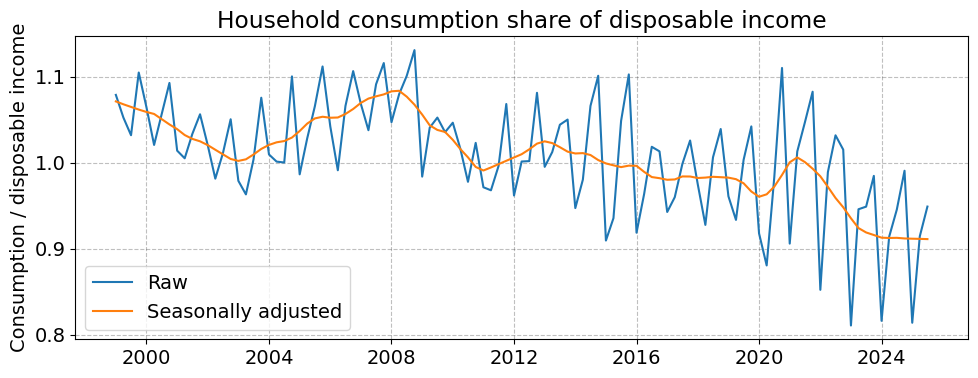

In [7]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,1,1)

ax.plot(wide.index, ratio, label='Raw')
ax.plot(wide.index, ratio_noseason, label='Seasonally adjusted')

ax.set_ylabel('Consumption / disposable income')
ax.set_title('Household consumption share of disposable income')
ax.legend()

fig.tight_layout()

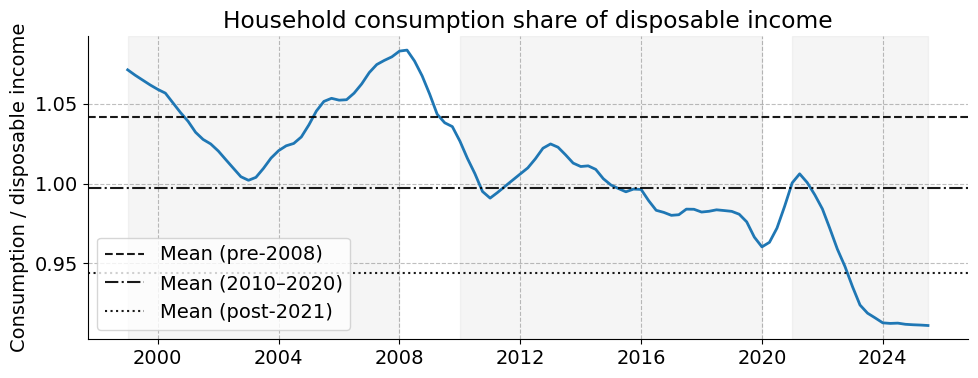

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ratio_noseason.index, ratio_noseason, lw=2)

# define regimes (start, end, label)
regimes = [
    (None, '2008-01-01', 'Mean (pre-2008)'),
    ('2010-01-01', '2020-01-01', 'Mean (2010–2020)'),
    ('2021-01-01', None, 'Mean (post-2021)'),
]

line_styles = ['--', '-.', ':']

for (start, end, lab), ls in zip(regimes, line_styles):
    idx = pd.Series(True, index=ratio_noseason.index)

    if start is not None:
        idx &= ratio_noseason.index >= pd.Timestamp(start)
    if end is not None:
        idx &= ratio_noseason.index < pd.Timestamp(end)

    m = ratio_noseason.loc[idx].mean()
    ax.axhline(m, color='k', ls=ls, lw=1.5, alpha=0.9, label=lab)

    # lightly shade the window used for that mean
    if start is not None or end is not None:
        x0 = ratio_noseason.index.min() if start is None else pd.Timestamp(start)
        x1 = ratio_noseason.index.max() if end is None else pd.Timestamp(end)
        ax.axvspan(x0, x1, color='k', alpha=0.04)

# labels + cosmetics
ax.set_ylabel('Consumption / disposable income')
ax.set_title('Household consumption share of disposable income')

ax.grid(True, which='major', axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
fig.tight_layout()
plt.show()

### 1.2. <a id='toc1_2_'></a>[Question 2](#toc0_)

In [9]:
NKHC021 = DstApi('NKHC021')
display(NKHC021.tablesummary(language='en'))

Table NKHC021: Final consumption of households on the economic territory (15 grp) by purpose, price unit, seasonal adjustment and time
Last update: 2025-12-22T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,FORMAAAL,16,CPT,Total,CPO,Other goods and services,False
1,PRISENHED,2,V,Current prices,LKV,"2020-prices, chained values",False
2,SÆSON,2,N,Non-seasonally adjusted,Y,Seasonally adjusted,False
3,Tid,143,1990K1,1990Q1,2025K3,2025Q3,True


In [10]:
print('FORMAAAL variable:')
FORMAAAL_dict = {row.id:row.text for row in NKHC021.variable_levels('FORMAAAL',language='en').itertuples()}
for varname in FORMAAAL_dict.keys():  print(f'Variable: {varname} - {FORMAAAL_dict[varname]}')

FORMAAAL variable:
Variable: CPT - Total
Variable: CPA - Food
Variable: CPB - Beverages, tobacco etc.
Variable: CPC - Clothing and footwear
Variable: CPD - Housing
Variable: CPE - Electricity, gas and other fuels
Variable: CPF - Furnishings, household equipment and routine household maintenance
Variable: CPG - Health
Variable: CPH - Purchase of vehicles
Variable: CPI - Operation of vehicles and other transport services
Variable: CPJ - Information and communication
Variable: CPK - Recreation, sport and culture
Variable: CPL - Education services
Variable: CPM - Restaurants and accommodation services
Variable: CPN - Insurance and financial services
Variable: CPO - Other goods and services


In [11]:
# a. download
params = {
    'table': 'NKHC021',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'FORMAAAL', 'values': ['*']},
        {'code': 'PRISENHED', 'values': ['V']},
        {'code': 'Sæson', 'values': ['Y']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

dfc = NKHC021.get_data(params=params)

# b. clean
dfc = dfc.drop(columns=['PRISENHED','SÆSON'])
dfc = dfc.rename(columns={'TID':'time','FORMAAAL':'item','INDHOLD':'value'})
dfc.time = pd.PeriodIndex(dfc.time,freq="Q").to_timestamp()
dfc = dfc.sort_values('time')

dfc.head()

,item,time,value
1615,Insurance and financial services,1990-01-01,5274
1609,Purchase of vehicles,1990-01-01,3715
1608,Health,1990-01-01,2446
1607,"Furnishings, household equipment and routine h...",1990-01-01,5498
1606,"Electricity, gas and other fuels",1990-01-01,6299


Comparison:

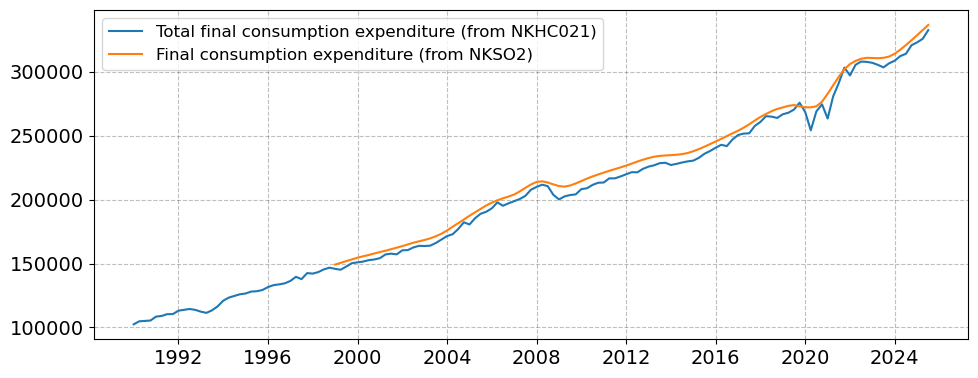

In [12]:
tot = dfc[dfc['item'].str.lower().eq('total')].set_index('time')['value']

fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1,1,1)

ax.plot(tot.index, tot.values, label='Total final consumption expenditure (from NKHC021)')
ax.plot(wide.index, wide.C_noseason, label='Final consumption expenditure (from NKSO2)')
ax.legend(fontsize=12)

fig.tight_layout()

Shares:

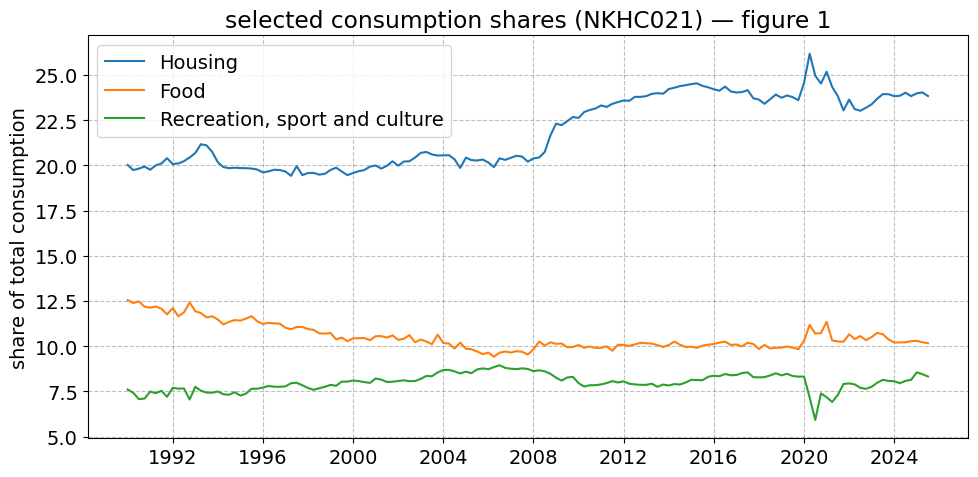

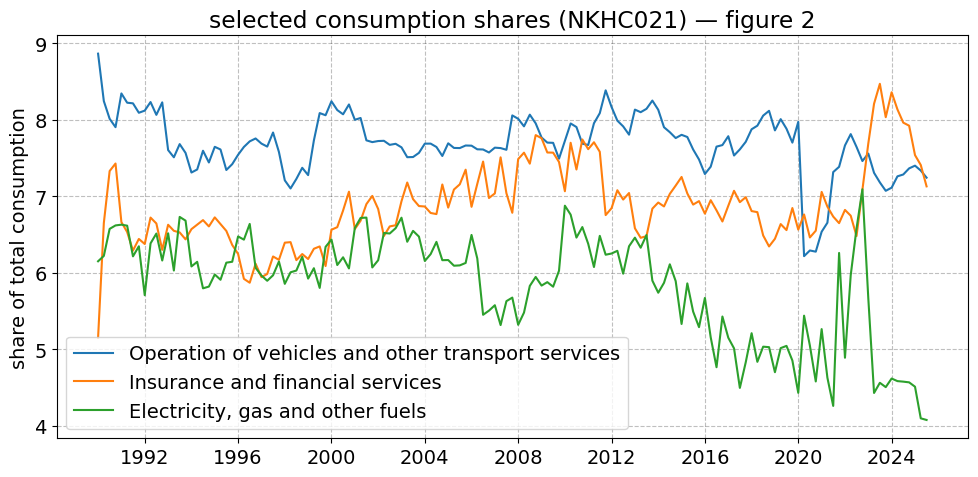

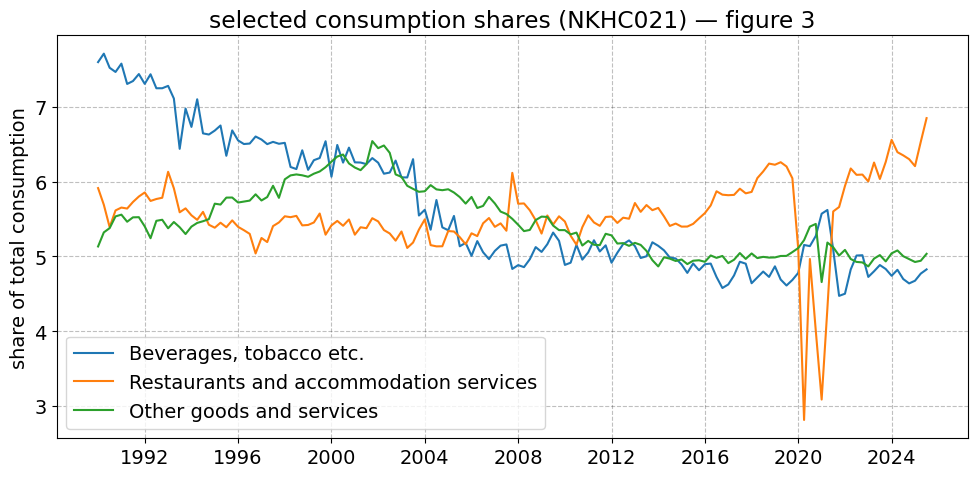

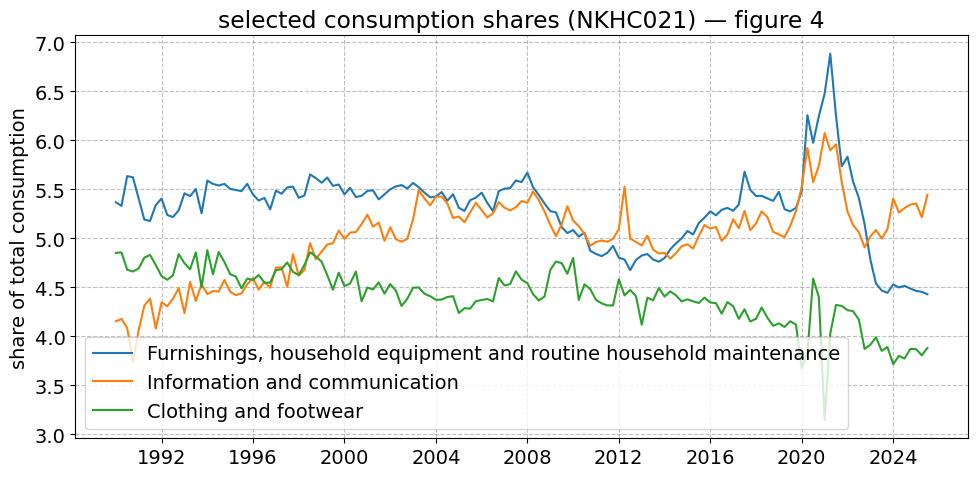

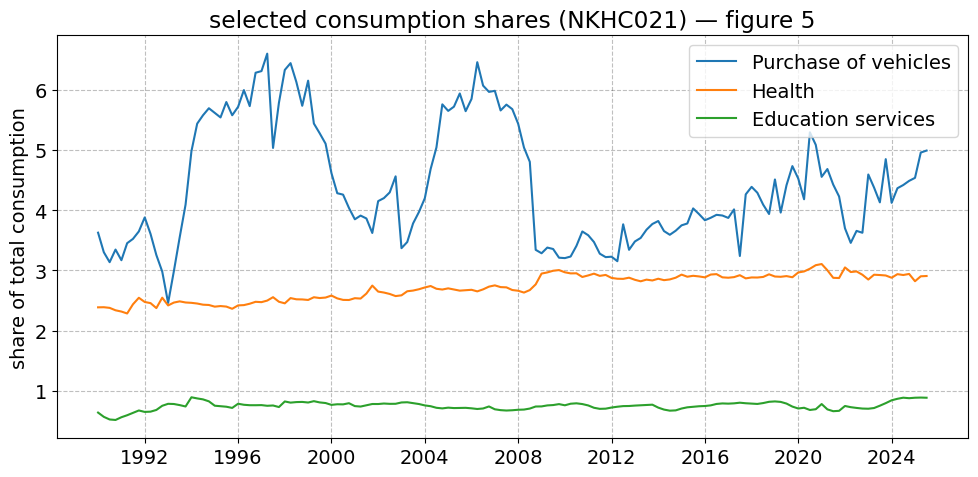

In [13]:
# a. compute shares within each time period
tot = (dfc[dfc['item'].str.lower().eq('total')][['time', 'value']]
       .set_index('time')
       .rename(columns={'value': 'value_total'}))

dfcs = dfc[dfc['item'].str.lower().ne('total')].copy()
dfcs = dfcs.join(tot, on='time', how='left')

dfcs['share'] = dfcs['value'] / dfcs['value_total'] * 100

# b. sorted average shares
top_items = (
    dfcs.groupby('item')['share']
       .mean()
       .sort_values(ascending=False)
       .index
       .tolist()
)

# c. chunk into groups of 3
chunks = [top_items[i:i+3] for i in range(0, len(top_items), 3)]

for k, items in enumerate(chunks, start=1):

    fig, ax = plt.subplots(figsize=(10, 5))

    for item in items:

        s = (dfcs[dfcs['item'] == item]
             .set_index('time')['share']
             .sort_index())
        ax.plot(s.index, s.values, label=item)

    ax.legend()
    ax.set_ylabel('share of total consumption')
    ax.set_title(f'selected consumption shares (NKHC021) — figure {k}')
    fig.tight_layout()
    plt.show()


### 1.3. <a id='toc1_3_'></a>[Question 3](#toc0_)

Since 1990:

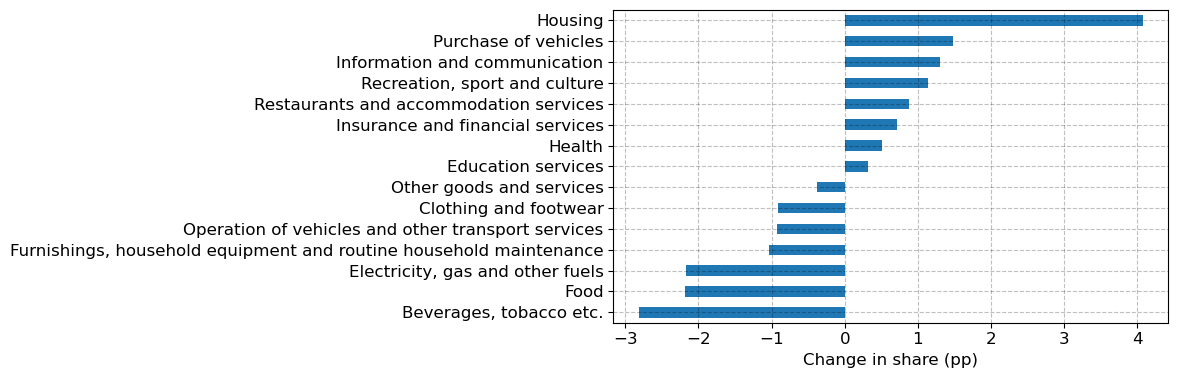

In [14]:
# a. compute
share_wide = dfcs.pivot(index='time',columns='item',values='share').sort_index()
first = share_wide.iloc[:4].mean()
last = share_wide.iloc[-3:].mean()
change = (last - first).sort_values()

# b. plot
fig, ax = plt.subplots(1, 1, figsize=(12,4))
change.plot(kind='barh', ax=ax, fontsize=12)
ax.set_ylabel('')
ax.set_xlabel('Change in share (pp)', fontsize=12)
fig.tight_layout()


Since 2020Q1:

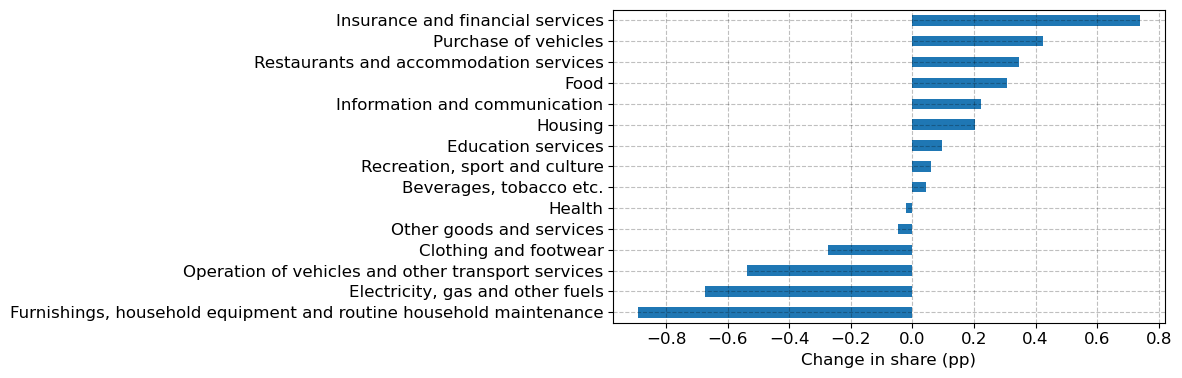

In [15]:
# a. compute
share_wide = share_wide[share_wide.index >= '2019-01-01']
first = share_wide.iloc[:4].mean()
last = share_wide.iloc[-3:].mean()
change = (last - first).sort_values()

# b. plot
fig, ax = plt.subplots(1, 1, figsize=(12,4))
change.plot(kind='barh', ax=ax, fontsize=12)
ax.set_ylabel('')
ax.set_xlabel('Change in share (pp)', fontsize=12)
fig.tight_layout()

## 2. <a id='toc2_'></a>[Problem 2: Labor supply with non-linear pay schedules](#toc0_)


In [16]:
from LaborSupplyModel_sol import LaborSupplyModelClass

In [17]:
model = LaborSupplyModelClass()
p = model.par

### 2.1. <a id='toc2_1_'></a>[Question 1](#toc0_)


 grid : l*=0.8434, c*=1.0434, u*=-0.4748
 opt  : l*=0.8435, c*=1.0435, u*=-0.4748
 foc  : l*=0.8435, c*=1.0435, u*=-0.4748


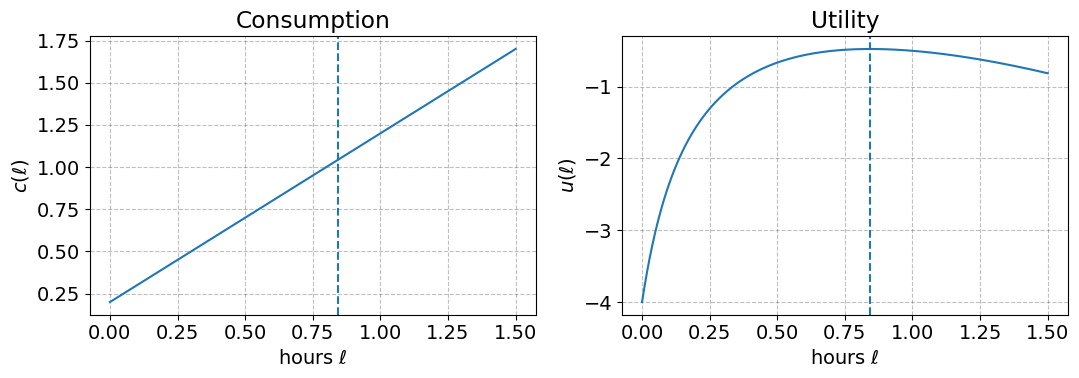

In [18]:
# a. grid and values
grid = np.linspace(0.0, p.l_max, 2000)
c = model.consumption(grid, WageSchedule='baseline')
u = model.utility(grid, WageSchedule='baseline')

# b. solve
sol_grid = model.solve_grid(WageSchedule='baseline', n=2000)
sol_opt = model.solve_local_opt(l0=0.5, WageSchedule='baseline')
sol_foc = model.solve_local_FOC(WageSchedule='baseline')

print(f' grid : l*={sol_grid['l_star']:.4f}, c*={sol_grid['c_star']:.4f}, u*={sol_grid['u_star']:.4f}')
print(f' opt  : l*={sol_opt['l_star']:.4f}, c*={sol_opt['c_star']:.4f}, u*={sol_opt['u_star']:.4f}')
print(f' foc  : l*={sol_foc['l_star']:.4f}, c*={sol_foc['c_star']:.4f}, u*={sol_foc['u_star']:.4f}')

# c. plot
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(grid, c)
ax[0].axvline(sol_grid['l_star'], linestyle='--')
ax[0].set_xlabel(r'hours $\ell$')
ax[0].set_ylabel('$c(\ell)$')
ax[0].set_title('Consumption')

ax[1].plot(grid, u)
ax[1].axvline(sol_foc['l_star'], linestyle='--')
ax[1].set_xlabel('hours $\ell$')
ax[1].set_ylabel('$u(\ell)$')
ax[1].set_title('Utility')

fig.tight_layout()

### 2.2. <a id='toc2_2_'></a>[Question 2](#toc0_)


Overtime solutions
 local (0.2) : l*=0.8435
 local (1.2) : l*=1.0487
 global      : l*=1.0487


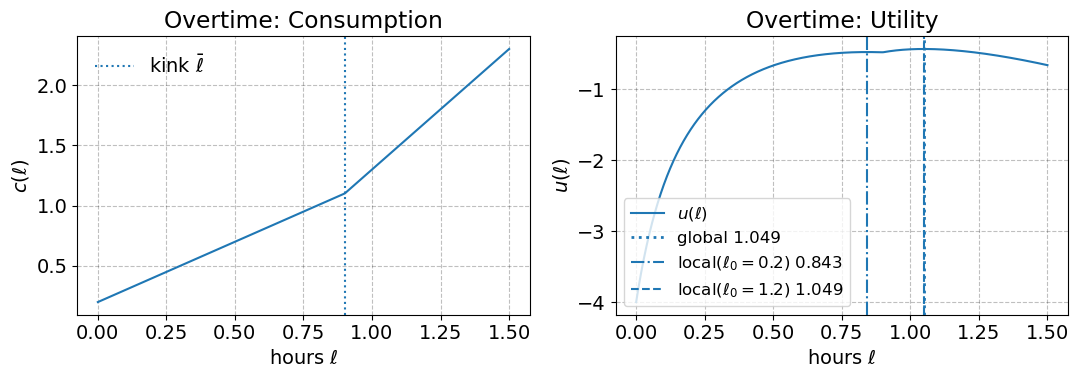

In [19]:
# a. grid and values
grid = np.linspace(0.0, p.l_max, 3000)
c = model.consumption(grid, WageSchedule='overtime')
u = model.utility(grid, WageSchedule='overtime')

# b. show local maxima behavior via different starting values
sol_local_low = model.solve_local_opt(l0=0.2, WageSchedule='overtime')
sol_local_high = model.solve_local_opt(l0=1.2, WageSchedule='overtime')

# c. robust solver
sol_global = model.solve_global(WageSchedule='overtime')

print('Overtime solutions')
print(f' local (0.2) : l*={sol_local_low['l_star']:.4f}')
print(f' local (1.2) : l*={sol_local_high['l_star']:.4f}')
print(f' global      : l*={sol_global['l_star']:.4f}')

# b. plot
fig, ax = plt.subplots(1, 2, figsize=(11,4))

ax[0].plot(grid, c)
ax[0].axvline(p.l_bar, linestyle=':', label=r'kink $\bar\ell$')
ax[0].set_xlabel(r'hours $\ell$');
ax[0].set_ylabel(r'$c(\ell)$');
ax[0].set_title('Overtime: Consumption')
ax[0].legend(frameon=False)

ax[1].plot(grid, u, label='$u(\ell)$')
ax[1].axvline(sol_global['l_star'], linestyle=':', linewidth=2, label=f'global {sol_global['l_star']:.3f}')
ax[1].axvline(sol_local_low['l_star'], linestyle='-.', label=fr'local($\ell_0=0.2$) {sol_local_low['l_star']:.3f}')
ax[1].axvline(sol_local_high['l_star'], linestyle='--', label=fr'local($\ell_0=1.2$) {sol_local_high['l_star']:.3f}')
ax[1].set_xlabel(r'hours $\ell$'); 
ax[1].set_ylabel(r'$u(\ell)$'); 
ax[1].set_title('Overtime: Utility')
ax[1].legend(loc='lower left', fontsize=12)

fig.tight_layout()

## 3. <a id='toc3_'></a>[Problem 3: Labor market simulation](#toc0_)

In [20]:
from LaborMarketModel_sol import LaborMarketModelClass

In [21]:
model = LaborMarketModelClass()

### 3.1. <a id='toc3_1_'></a>[Question 1](#toc0_)

In [22]:
# a. run baseline simulation (stores only the last 200 periods)
res = model.simulate(T=3_000, store_last=200)

y = res['y_last'] # (200, N)
employed = res['employed_last'].astype(bool) # (200, N)
duration = res['duration_last'] # (200, N)
types = res['types'] # (N,)

# b. split into two halves: -200:-100 and -100:
y_1, y_2 = y[:100], y[100:]
emp_1, emp_2 = employed[:100], employed[100:]
dur_1, dur_2 = duration[:100], duration[100:]

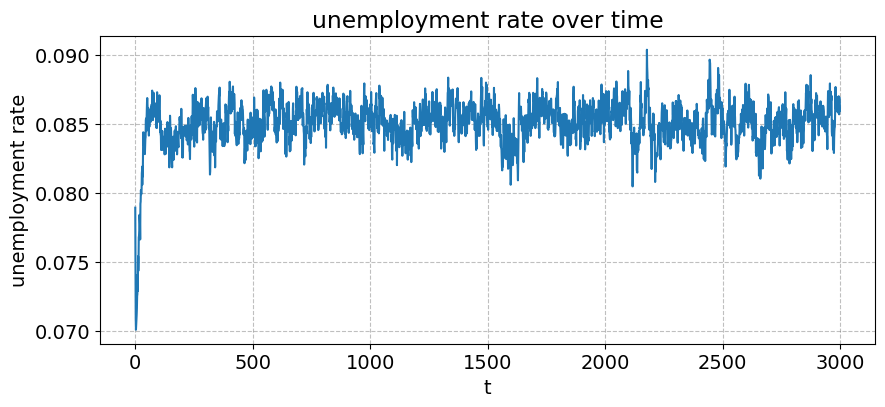

In [23]:
# optional sanity check: selected moments over time
u = res['u_rate']
mean_logy = res['mean_logy']
std_logy = res['std_logy']

plt.figure(figsize=(10,4))
plt.plot(u)
plt.xlabel('t')
plt.ylabel('unemployment rate')
plt.title('unemployment rate over time')
plt.show()

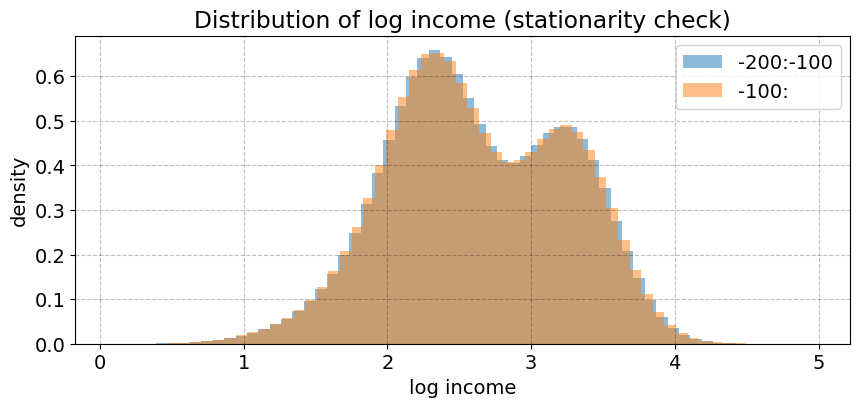

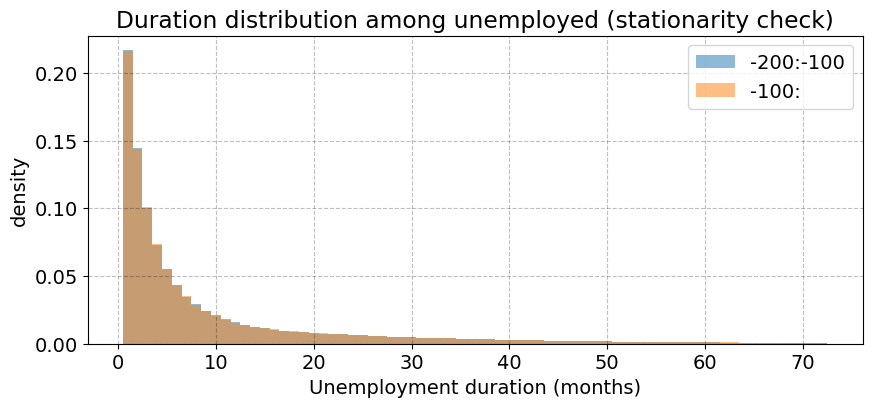

In [24]:
# compare distributions in -200:-100 vs -100:
logy_1 = np.log(np.maximum(y_1.reshape(-1), 1e-12))
logy_2 = np.log(np.maximum(y_2.reshape(-1), 1e-12))

# unemployment durations among unemployed (pool across i,t)
dur_u_1 = dur_1[~emp_1]
dur_u_2 = dur_2[~emp_2]

plt.figure(figsize=(10,4))
plt.hist(logy_1, bins=60, density=True, alpha=0.5, label='-200:-100')
plt.hist(logy_2, bins=60, density=True, alpha=0.5, label='-100:')
plt.xlabel('log income')
plt.ylabel('density')
plt.title('Distribution of log income (stationarity check)')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
bins = np.arange(1, np.percentile(np.concatenate([dur_u_1, dur_u_2]), 99) + 2) - 0.5
plt.hist(dur_u_1, bins=bins, density=True, alpha=0.5, label='-200:-100')
plt.hist(dur_u_2, bins=bins, density=True, alpha=0.5, label='-100:')
plt.xlabel('Unemployment duration (months)')
plt.ylabel('density')
plt.title('Duration distribution among unemployed (stationarity check)')
plt.legend()
plt.show()

In [25]:
def pooled_moments(y_panel, emp_panel):
    """Moments pooled across all individuals and periods in the panel."""
    
    y_flat = y_panel.reshape(-1)
    emp_flat = emp_panel.reshape(-1)

    u_rate = float((~emp_flat).mean())
    logy = np.log(np.maximum(y_flat, 1e-12))
    return {
        'u_rate': u_rate,
        'mean_logy': float(logy.mean()),
        'std_logy': float(logy.std()),
    }

m1 = pooled_moments(y_1, emp_1)
m2 = pooled_moments(y_2, emp_2)

pd.DataFrame([m1, m2], index=['-200:-100', '-100:'])

,u_rate,mean_logy,std_logy
-200:-100,0.085613,2.630925,0.622320
-100:,0.085644,2.631395,0.622812


### 3.2. <a id='toc3_2_'></a>[Compare low- vs high-skilled](#toc0_)


In [26]:
def type_summary(types, y_panel, emp_panel, dur_panel):

    out = []
    for s, name in [(0, 'Low-skilled (L)'), (1, 'High-skilled (H)')]:

        mask = (types == s)

        y_s = y_panel[:, mask].reshape(-1)
        emp_s = emp_panel[:, mask].reshape(-1)
        dur_s = dur_panel[:, mask].reshape(-1)

        logy_s = np.log(np.maximum(y_s, 1e-12))

        u_rate = float((~emp_s).mean())
        mean_logy = float(logy_s.mean())
        std_logy = float(logy_s.std())

        dur_u = dur_s[~emp_s]
        mean_dur_u = float(dur_u.mean()) if dur_u.size > 0 else np.nan
        share_long_u = float((dur_u >= 12).mean()) if dur_u.size > 0 else np.nan

        out.append({
            'type': name,
            'u_rate': u_rate,
            'mean_logy': mean_logy,
            'std_logy': std_logy,
            'mean_duration_u': mean_dur_u,
            'share_duration_ge_12': share_long_u,
        })

    return pd.DataFrame(out).set_index('type')

# use the full stored panel (200 periods)
type_summary(types, y, employed, duration)

,u_rate,mean_logy,std_logy,mean_duration_u,share_duration_ge_12
type,,,,,
Low-skilled (L),0.113399,2.228342,0.405769,12.162233,0.310119
High-skilled (H),0.043985,3.235237,0.337155,2.432515,0.006768


### 3.3. <a id='toc3_3_'></a>[Question 3](#toc0_)

In [27]:
# Idea: start from the baseline and then set ONE high-skilled parameter equal to
# the low-skilled value (or vice versa), rerun, and see how the gaps change.

def compute_gaps(res):
    
    y = res['y_last']
    emp = res['employed_last'].astype(bool)
    dur = res['duration_last']
    types = res['types']

    summ = type_summary(types, y, emp, dur)

    gap = {
        'gap_u_rate (H-L)': float(summ.loc['High-skilled (H)', 'u_rate'] - summ.loc['Low-skilled (L)', 'u_rate']),
        'gap_mean_logy (H-L)': float(summ.loc['High-skilled (H)', 'mean_logy'] - summ.loc['Low-skilled (L)', 'mean_logy']),
        'gap_mean_duration_u (H-L)': float(summ.loc['High-skilled (H)', 'mean_duration_u'] - summ.loc['Low-skilled (L)', 'mean_duration_u']),
    }
    return gap

baseline_gaps = compute_gaps(res)

experiments = {
    'baseline': {},
    'set a_H = a_L': {'a_H': model.par.a_L},
    'set mu_H = mu_L': {'mu_H': model.par.mu_L},
    'set f0_H = f0_L': {'f0_H': model.par.f0_L},
    'set lambda_H = lambda_L': {'lambda_H': model.par.lambda_L},
}

results = []
for name, changes in experiments.items():

    # new model with modified parameters
    m_cf = LaborMarketModelClass(changes)
    res_cf = m_cf.simulate(T=3_000, store_last=200)

    gaps = compute_gaps(res_cf)
    gaps['experiment'] = name
    results.append(gaps)

pd.DataFrame(results).set_index('experiment')


,gap_u_rate (H-L),gap_mean_logy (H-L),gap_mean_duration_u (H-L)
experiment,,,
baseline,-0.069414,1.006895,-9.729718
set a_H = a_L,-0.069414,0.606895,-9.729718
set mu_H = mu_L,-0.069414,0.506895,-9.729718
set f0_H = f0_L,-0.031601,0.949521,-6.717856
set lambda_H = lambda_L,-0.064177,0.998959,-8.157201
